# 04 — Baseline 2: Greedy Move Heuristic

For each order that needs a decision, we look at the other DCs. If one of them fills the order
better and the rules allow it, we move the order there. We handle **one order at a time and never go
back**. That is what greedy means.

We run it twice, because the answer depends on who goes first:

* **2A** biggest revenue first.
* **2B** biggest shortfall first.

This notebook runs on its own. It reads nothing from other notebooks and it saves nothing.

## 1. Setup

This notebook runs on its own. It reads the data files, does its own work, and prints the results.
It does not upload anything, and it does not save any files.

Set `DATA_DIR` below to the folder that holds the CSV files. If the folder is somewhere under the
current directory, the notebook finds it by itself.

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# Put the path to your data folder here, or leave it as None to search for it.
DATA_DIR = None

def find_data(start=DATA_DIR):
    """Return the folder that holds input_order data.csv."""
    if start and os.path.isfile(os.path.join(start, "input_order data.csv")):
        return start
    for hit in glob.glob("**/input_order data.csv", recursive=True):
        return os.path.dirname(hit)          # first match wins
    raise FileNotFoundError(
        "Could not find 'input_order data.csv'. Set DATA_DIR to the folder that holds the CSV files.")

IN = find_data()                              # folder with the 5 input files
ROOT = os.path.dirname(IN) if os.path.basename(IN) == "input data" else IN
print("input folder :", IN)

input folder : drive/MyDrive/DOM/dom_extract/Nestle - WISER WQ26 DOM-data [SHARED]/DOM-data/input data


## 2. Read the data

Five input files. Two output files come from the earlier model run; we use them only to check our
own numbers, never as input.

In [3]:
orders = pd.read_csv(f"{IN}/input_order data.csv")            # one row per order and SKU
cap    = pd.read_csv(f"{IN}/input_capacity_planning.csv")     # daily stock per DC and SKU
dock   = pd.read_csv(f"{IN}/input_dock_capacity.csv")         # daily dock slots per DC
ship   = pd.read_csv(f"{IN}/input_shipping_cost_data.csv")    # cost per DC to zip lane
thru   = pd.read_csv(f"{IN}/input_throughput_capacity.csv")   # daily pick work per DC

def read_output(name):
    """The two output files may sit beside the input folder or one level up."""
    for p in [f"{ROOT}/{name}", f"{IN}/{name}", f"{ROOT}/../{name}"]:
        if os.path.isfile(p):
            return pd.read_csv(p)
    return None

poc_ord = read_output("Output_order_level_data.csv")          # check only
poc_sku = read_output("output_order_sku_level_data.csv")      # check only

for n, d in [("orders", orders), ("capacity", cap), ("dock", dock),
             ("shipping", ship), ("throughput", thru)]:
    print(f"{n:11s} {d.shape}")

orders      (25193, 39)
capacity    (377504, 23)
dock        (480, 13)
shipping    (12922, 7)
throughput  (530, 7)


## 3. Prepare the orders

Four small steps: parse the dates, put every line into cases, work out a price per case, and roll the
lines up to one row per order.

In [4]:
orders["PGI"] = pd.to_datetime(orders["transportationplanningdate"], format="%m/%d/%y")  # ship day
orders["RDD"] = pd.to_datetime(orders["RequestedDeliveryDate"],      format="%m/%d/%y")  # due day
orders["IsInvAvail"] = orders["IsInvAvail"].astype(str).str.strip().str.upper()

# Lines measured in pallets become cases, so everything is in the same unit.
orders["cases"] = np.where(orders["ProductPlanningUnitOfMeasure"].eq("PL"),
                           orders["OrderedQty_converted"] * orders["ProductCasesPerPallet"],
                           orders["OrderedQty_converted"]).astype(float)

# Price per case lets us rebuild revenue from the cases we actually fill.
orders["price_per_case"] = np.where(orders["cases"] > 0,
                                    orders["Order_SKU_Revenue"] / orders["cases"], 0.0)
orders["cpp"] = orders["ProductCasesPerPallet"].replace(0, np.nan).fillna(1).astype(float)

# One row per order.
head = orders.groupby("Group_Flag").agg(
    default_dc=("Plant", "first"),            # the DC it uses today
    pgi=("PGI", "first"),                     # planned ship day
    rdd=("RDD", "first"),                     # customer due day
    zipc=("ZipCode", "first"),                # ship-to zip, for the freight cost
    prio=("DeliveryPriority", "min"),         # 8 = protected order, 99 = normal
    revenue=("Order_SKU_Revenue", "sum"),
    ordered_cases=("cases", "sum"),
    frt=("FillRateThreshold", "first"),       # fill % below which a penalty starts
    ppc=("Penaltyforpotentialcuts", "first"), # penalty rate on the missing value
).reset_index()
head[["frt", "ppc"]] = head[["frt", "ppc"]].fillna(0.0)
head["threshold_cases"] = head["frt"] * head["ordered_cases"]

HEAD  = head.set_index("Group_Flag").to_dict("index")
LINES = {gf: [(int(r.MaterialNumber), float(r.cases), float(r.price_per_case), float(r.cpp))
              for r in g.itertuples(index=False)]
         for gf, g in orders.groupby("Group_Flag", sort=False)}

print("orders:", len(head), "| SKUs:", orders.MaterialNumber.nunique(),
      "| DCs:", orders.Plant.nunique())

orders: 1109 | SKUs: 1110 | DCs: 8


## 4. Find the focus orders

An order needs a decision for one of two reasons. Either it is short of stock at its own DC, or it
ships on a day when that DC has no dock slot left. Everything else is fine and stays where it is.

In [5]:
# Short of stock: any line of the order has IsInvAvail = N.
roll   = orders.groupby("Group_Flag")["IsInvAvail"].apply(lambda s: (s == "Y").all())
SUFF   = set(roll[roll].index)
INSUFF = set(roll[~roll].index)

# No dock left on the planned ship day.
dock["Date"] = pd.to_datetime(dock["Date"], format="%m/%d/%y")
zero_days = set(map(tuple, dock.loc[dock["Dock_Remaining"] == 0, ["Plant", "Date"]]
                              .drop_duplicates().values))
ADDED = {gf for gf, h in HEAD.items()
         if (h["default_dc"], h["pgi"]) in zero_days} & SUFF

FOCUS = sorted(INSUFF | ADDED)                        # the orders the model decides
CLEAN_ORDERS = sorted(set(HEAD) - set(FOCUS))         # the orders that stay put

print(f"{len(INSUFF)} short of stock + {len(ADDED)} with no dock = {len(FOCUS)} focus orders")
print(f"{len(CLEAN_ORDERS)} orders are fine and stay where they are")

447 short of stock + 25 with no dock = 472 focus orders
637 orders are fine and stay where they are


## 5. Build the stock, dock and capacity tables

Everything that changes by day sits on the same day grid, so "the next 5 days" is just a slice of an
array.

In [6]:
cap["DATE"] = pd.to_datetime(cap["DATE"])
DATES = pd.date_range(cap["DATE"].min(), cap["DATE"].max(), freq="D")
NT    = len(DATES)                                    # number of days
DIX   = {d: i for i, d in enumerate(DATES)}           # date -> position
DCS   = sorted(int(x) for x in orders["Plant"].unique())
DCIX  = {d: i for i, d in enumerate(DCS)}             # DC -> row number

# Free stock = opening stock minus what is already reserved.
cap["AV"] = cap["OpeningStock"] - cap["Total_Reserved_Qty"]
POOL0 = {}
for (d, s), g in cap[cap["LocationID"].isin(DCS)].groupby(["LocationID", "MaterialID"], sort=False):
    arr = np.zeros(NT)
    ix  = g["DATE"].map(DIX).dropna().astype(int).values
    arr[ix] = g["AV"].values[:len(ix)]
    POOL0[(int(d), int(s))] = arr                     # one stock line per DC and SKU

SKU_AT_DC = {}
for (d, s) in POOL0:
    SKU_AT_DC.setdefault(d, set()).add(s)             # which DC stocks which SKU

# Freight cost and distance for each DC to zip lane.
SHIP = {(int(r.Plant), int(r.TargetZip)): float(r.Shipping_Cost)
        for r in ship.itertuples(index=False)}
DIST = {(int(r.Plant), int(r.TargetZip)): float(r.Distance)
        for r in ship.itertuples(index=False)}

# Free dock slots. Two DCs have no rows at all, so we mark them "no data" and skip the check there.
DOCK0 = np.full((len(DCS), NT), np.nan)
for r in dock.itertuples(index=False):
    if r.Plant in DCIX and r.Date in DIX:
        DOCK0[DCIX[r.Plant], DIX[r.Date]] = max(0.0, float(r.Dock_Remaining))
DOCK_HAS = ~np.isnan(DOCK0)
DOCK0    = np.nan_to_num(DOCK0, nan=0.0)

# Pick capacity. The file gives usage only, so we take the highest usage as the limit.
thru["transportationplanningdate"] = pd.to_datetime(thru["transportationplanningdate"])
CP_CAP = thru.groupby("Plant")["util_case_picks"].max().to_dict()
PP_CAP = thru.groupby("Plant")["util_pallets"].max().to_dict()
CP0 = np.zeros((len(DCS), NT)); PP0 = np.zeros((len(DCS), NT))
for d in DCS:
    CP0[DCIX[d], :] = CP_CAP.get(d, 0.0)
    PP0[DCIX[d], :] = PP_CAP.get(d, 0.0)
for r in thru.itertuples(index=False):
    if r.Plant in DCIX and r.transportationplanningdate in DIX:
        i, j = DCIX[r.Plant], DIX[r.transportationplanningdate]
        CP0[i, j] = max(0.0, CP_CAP[r.Plant] - r.util_case_picks)
        PP0[i, j] = max(0.0, PP_CAP[r.Plant] - r.util_pallets)

print("days:", NT, "| DCs:", DCS, "| DC-SKU stock lines:", len(POOL0))

days: 32 | DCs: [5083, 5385, 5410, 5420, 5490, 5620, 5641, 5773] | DC-SKU stock lines: 11550


## 6. The rules and the objective

The business rules from the project documents, written as small functions.

**Objective = Revenue − Penalty − Shipping cost**

| Rule | What it means |
|---|---|
| C1 | One order goes to one DC only |
| C2 | You cannot fill more than what was ordered |
| C3 | Stock must be there, and must still cover the next 5 days |
| C4 | Move only if the fill rises 5 points **and** 100 cases |
| C5 | Case picks and pallet picks must fit the DC limit that day |
| C6 | One dock slot per order, and docks are limited |
| C7 | A penalty applies only if filled cases fall under the order threshold |

In [7]:
CFG = dict(
    MIN_FILL_LIFT_PP   = 0.05,   # C4: the fill must rise 5 points
    MIN_CASE_LIFT      = 100.0,  # C4: and at least 100 cases
    FORWARD_COVER_DAYS = 5,      # C3: stock must last 5 more days
    LEAD_TIME_MILES    = 500.0,  # one transit day per 500 miles
    DOCKS_PER_ORDER    = 1,      # C6: one dock per order
    SAFETY_STOCK_FRAC  = 0.0,    # hold back stock elsewhere (sensitivity only)
    REQUIRE_OBJ_GAIN   = True,   # greedy only: move only if the money improves
)

def avail(P, d, s, t, window=0):
    """C3: how many cases we may take. With a window, the tightest day decides."""
    a = P.get((d, s))
    if a is None:
        return 0.0
    hi = min(NT, t + window + 1)
    return max(0.0, a[t:hi].min()) if hi > t else 0.0

def take(P, d, s, t, q):
    a = P.get((d, s))
    if a is not None and q > 0:
        a[t:] -= q                                  # gone from today and every later day

def give(P, d, s, t, q):
    a = P.get((d, s))
    if a is not None and q > 0:
        a[t:] += q                                  # put it back the same way

def evaluate(P, gf, d, t, window=0, reserve=0.0):
    """C2 and C3: how much of this order this DC can fill on this day."""
    fills, by, tot, rev = [], {}, 0.0, 0.0
    for s, dem, price, cpp in LINES[gf]:
        q = min(dem, avail(P, d, s, t, window) * (1.0 - reserve))   # never more than ordered
        fills.append((s, q, price, cpp)); by[s] = q; tot += q; rev += q * price
    return fills, by, tot, rev

def picks(fills):
    """C5: full pallets are pallet picks, the rest are case picks."""
    cp = pp = 0.0
    for _, q, _, cpp in fills:
        if q <= 0:
            continue
        full = math.floor(q / cpp); pp += full; cp += q - full * cpp
    return cp, pp

def penalty_of(gf, by, tot):
    """C7: no penalty if we reach the threshold, otherwise charge for what is missing."""
    h = HEAD[gf]
    if h["ppc"] <= 0 or tot >= h["threshold_cases"]:
        return 0.0
    return max(0.0, sum((dem - by.get(s, 0.0)) * price * h["ppc"]
                        for s, dem, price, _ in LINES[gf]))

def objective(rec):
    """Revenue minus penalty minus shipping."""
    return rec["revenue"] - rec["pen"] - rec["ship"]

def lead_time(d, z):
    dd = DIST.get((d, z))
    return None if dd is None else max(1, int(math.ceil(dd / CFG["LEAD_TIME_MILES"])))

def revised_pgi(gf, d):
    """A farther DC needs more transit time, so the ship day moves earlier."""
    h = HEAD[gf]; lt = lead_time(d, h["zipc"])
    if lt is None:
        return None, "no_lane"
    p = min(h["pgi"], h["rdd"] - pd.Timedelta(days=lt))
    while p.weekday() >= 5:                          # step back off Saturday and Sunday
        p -= pd.Timedelta(days=1)
    return (None, "pgi_out_of_horizon") if p not in DIX else (p, None)

def passes_gate(lift, ordered, cfg=CFG):
    """C4: the move must be worth making."""
    if lift < cfg["MIN_FILL_LIFT_PP"] * ordered:
        return "fail_5pct"
    if lift < cfg["MIN_CASE_LIFT"]:
        return "fail_100cases"
    return None

print("rules ready")

rules ready


## 7. Put every order at its own DC

This is the starting point. Protected orders (priority 8) go first, then the largest by revenue.
Each order takes its stock, so the next order sees what is left. This is also **Baseline 1**.

In [8]:
def stage_A():
    P = {k: v.copy() for k, v in POOL0.items()}      # work on a copy of the stock
    seq = head.sort_values(["prio", "revenue"], ascending=[True, False])["Group_Flag"]
    out = {}
    for gf in seq:
        h = HEAD[gf]; d = h["default_dc"]; t = DIX[h["pgi"]]
        fills, by, tot, rev = evaluate(P, gf, d, t, window=0)
        for s, q, _, _ in fills:
            take(P, d, s, t, q)                      # remove that stock for good
        cp, pp = picks(fills)
        out[gf] = dict(dc=d, t=t, fills=fills, by=by, filled=tot, revenue=rev, cp=cp, pp=pp,
                       pen=penalty_of(gf, by, tot), ship=SHIP.get((d, h["zipc"]), 0.0),
                       cof=tot / h["ordered_cases"] if h["ordered_cases"] else 0.0)
    return P, out

POOL_A, DEF = stage_A()
print("done:", len(DEF), "orders placed")

done: 1109 orders placed


## 8. The greedy pass

For each focus order, in the chosen order:

1. look at every other DC,
2. check in turn — does it stock the SKUs, does the new date work, is there stock (C3), does it pass
   the gate (C4), is there a dock (C6), is there pick room (C5),
3. keep the DC with the best objective,
4. if that beats staying put, give the stock back at the old DC and take it at the new one.

Every rejection is logged, so we can see which rule blocks the most moves.

In [9]:
def greedy(order_key, cfg=None):
    cfg = {**CFG, **(cfg or {})}
    P = {k: v.copy() for k, v in POOL_A.items()}     # stock left after stage A
    dk, cp_r, pp_r = DOCK0.copy(), CP0.copy(), PP0.copy()

    for gf, r in DEF.items():                        # every order already holds a dock slot
        i, j = DCIX[r["dc"]], r["t"]
        if DOCK_HAS[i, j]:
            dk[i, j] = max(0.0, dk[i, j] - cfg["DOCKS_PER_ORDER"])

    res = {g: dict(DEF[g], diverted=False, chosen_dc=DEF[g]["dc"], lift=0.0) for g in DEF}
    log = []

    for gf in sorted(FOCUS, key=order_key):          # <-- the greedy order
        h, base = HEAD[gf], DEF[gf]
        d0, t0 = base["dc"], base["t"]
        best = None

        for d in DCS:
            if d == d0:
                continue
            if not all(s in SKU_AT_DC.get(d, set()) for s, _, _, _ in LINES[gf]):
                log.append((gf, d, "sku_not_carried")); continue
            p, err = revised_pgi(gf, d)
            if err:
                log.append((gf, d, err)); continue
            t = DIX[p]
            fills, by, tot, rev = evaluate(P, gf, d, t,
                                           cfg["FORWARD_COVER_DAYS"], cfg["SAFETY_STOCK_FRAC"])
            lift = tot - base["filled"]
            g = passes_gate(lift, h["ordered_cases"], cfg)
            if g:
                log.append((gf, d, g)); continue
            i = DCIX[d]
            if DOCK_HAS[i, t] and dk[i, t] < cfg["DOCKS_PER_ORDER"]:
                log.append((gf, d, "no_dock")); continue
            cp, pp = picks(fills)
            if cp > cp_r[i, t] or pp > pp_r[i, t]:
                log.append((gf, d, "no_pick_capacity")); continue
            cand = dict(dc=d, t=t, fills=fills, by=by, filled=tot, revenue=rev,
                        pen=penalty_of(gf, by, tot), ship=SHIP.get((d, h["zipc"]), 0.0),
                        cp=cp, pp=pp, lift=lift,
                        cof=tot / h["ordered_cases"] if h["ordered_cases"] else 0.0)
            if best is None or objective(cand) > objective(best):
                best = cand

        if best is None:
            log.append((gf, None, "no_feasible_alternate")); continue
        if cfg["REQUIRE_OBJ_GAIN"] and objective(best) <= objective(base):
            log.append((gf, best["dc"], "no_objective_gain")); continue

        for s, q, _, _ in base["fills"]:
            give(P, d0, s, t0, q)                    # hand the stock back
        if DOCK_HAS[DCIX[d0], t0]:
            dk[DCIX[d0], t0] += cfg["DOCKS_PER_ORDER"]
        for s, q, _, _ in best["fills"]:
            take(P, best["dc"], s, best["t"], q)     # take it at the new DC
        i = DCIX[best["dc"]]
        if DOCK_HAS[i, best["t"]]:
            dk[i, best["t"]] -= cfg["DOCKS_PER_ORDER"]
        cp_r[i, best["t"]] -= best["cp"]
        pp_r[i, best["t"]] -= best["pp"]
        res[gf] = dict(best, diverted=True, chosen_dc=best["dc"])

    return res, pd.DataFrame(log, columns=["order", "dc", "reason"])

print("greedy ready")

greedy ready


## 9. Run both orderings

In [10]:
def metrics(res, label, runtime=None):
    """The same scorecard for every method, measured on the focus orders."""
    oc = sum(HEAD[g]["ordered_cases"] for g in FOCUS)
    fl = sum(res[g]["filled"] for g in FOCUS)
    return dict(scenario=label,
                objective_focus=sum(objective(res[g]) for g in FOCUS),
                objective_all=sum(objective(res[g]) for g in res),
                fill_rate=fl / oc, cases_filled=fl,
                orders_moved=sum(1 for g in FOCUS if res[g]["diverted"]),
                penalty_cost=sum(res[g]["pen"] for g in FOCUS),
                shipping_cost=sum(res[g]["ship"] for g in FOCUS),
                runtime_s=runtime)

def show(m):
    for k, v in m.items():
        print(f"{k:17s} {v:,.4f}" if isinstance(v, float) else f"{k:17s} {v}")


import time
KEYS = {"2A - by order value"      : lambda g: -HEAD[g]["revenue"],
        "2B - by shortage severity": lambda g: -(HEAD[g]["ordered_cases"] - DEF[g]["filled"])}

BASE1 = {g: dict(DEF[g], diverted=False, chosen_dc=DEF[g]["dc"]) for g in DEF}
rows = [metrics(BASE1, "Baseline 1 - leave everything", 0.0)]
runs = {}
for name, k in KEYS.items():
    t0 = time.time()
    r, lg = greedy(k)
    rows.append(metrics(r, f"Greedy {name}", round(time.time() - t0, 2)))
    runs[name] = (r, lg)
    print(f"{name:28s} moved {rows[-1]['orders_moved']:3d} orders   {rows[-1]['runtime_s']}s")

2A - by order value          moved  41 orders   0.47s
2B - by shortage severity    moved  39 orders   0.44s


### 9.1 Compared with leaving everything alone

Greedy buys fill rate and pays for it in freight. The objective decides if that was a good trade.

In [11]:
comp = pd.DataFrame(rows).set_index("scenario")
b1 = comp.iloc[0]
print(pd.DataFrame({
    "change in objective ($)": comp["objective_focus"] - b1["objective_focus"],
    "change in fill (points)": (comp["fill_rate"] - b1["fill_rate"]) * 100,
    "change in penalty ($)"  : comp["penalty_cost"] - b1["penalty_cost"],
    "change in freight ($)"  : comp["shipping_cost"] - b1["shipping_cost"],
    "orders moved"           : comp["orders_moved"],
}).round(2).to_string())

                                  change in objective ($)  change in fill (points)  change in penalty ($)  change in freight ($)  orders moved
scenario                                                                                                                                      
Baseline 1 - leave everything                        0.00                     0.00                   0.00                    0.0             0
Greedy 2A - by order value                      444610.19                     0.81               -9490.47                72686.0            41
Greedy 2B - by shortage severity                420484.74                     0.79               -9320.11                71337.0            39


### 9.2 Why orders could not move

This is the useful part for a planner: which rule blocks the most moves.

                       count  share
reason                             
fail_5pct               1682  46.0%
sku_not_carried         1457  39.8%
no_feasible_alternate    423  11.6%
fail_100cases             37   1.0%
pgi_out_of_horizon        24   0.7%
no_dock                   17   0.5%
no_pick_capacity          11   0.3%
no_objective_gain          8   0.2%


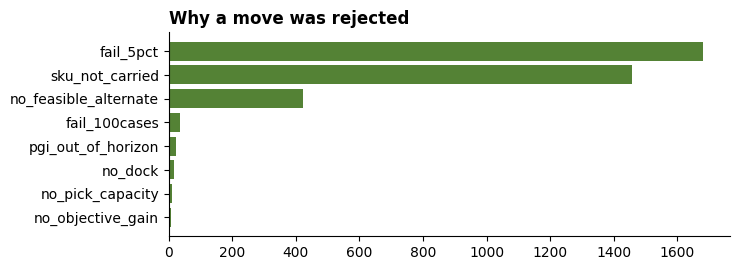

In [12]:
res2A, log2A = runs["2A - by order value"]
rej = log2A.reason.value_counts().rename("count").to_frame()
rej["share"] = (rej["count"] / rej["count"].sum()).map(lambda v: f"{v*100:.1f}%")
print(rej.to_string())

fig, ax = plt.subplots(figsize=(7.5, 2.8))
ax.barh(rej.index[::-1], rej["count"][::-1], color="#548235")
ax.set_title("Why a move was rejected", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 9.3 Where the moved orders went

In [13]:
div = pd.DataFrame([dict(order=g, from_dc=DEF[g]["dc"], to_dc=res2A[g]["chosen_dc"],
                         extra_cases=res2A[g]["lift"],
                         penalty_saved=DEF[g]["pen"] - res2A[g]["pen"],
                         extra_freight=res2A[g]["ship"] - DEF[g]["ship"],
                         net_gain=objective(res2A[g]) - objective(DEF[g]))
                    for g in FOCUS if res2A[g]["diverted"]])
print("orders moved:", len(div))
print()
print(div.groupby("to_dc")[["extra_cases", "penalty_saved", "extra_freight", "net_gain"]]
         .agg(["count", "sum"]).round(0).to_string())

orders moved: 41

      extra_cases         penalty_saved         extra_freight          net_gain          
            count     sum         count     sum         count      sum    count       sum
to_dc                                                                                    
5385            4  1231.0             4   267.0             4   6554.0        4   39814.0
5410            2  1216.0             2    67.0             2   4215.0        2   23007.0
5420            9  2504.0             9  4905.0             9  14173.0        9  130105.0
5490           15  4557.0            15  2518.0            15  27611.0       15  164927.0
5620            5  1227.0             5   712.0             5  17344.0        5   35040.0
5641            3   452.0             3  1022.0             3    948.0        3   26656.0
5773            3   525.0             3     0.0             3   1841.0        3   25061.0


## 10. Sensitivity

One setting changed at a time. This shows how much each rule is worth.

In [14]:
sens = []
for label, cfg in [("gate as written (5 pts + 100 cases)", {}),
                   ("no 100-case floor",                   {"MIN_CASE_LIFT": 0.0}),
                   ("stricter gate (10 points)",           {"MIN_FILL_LIFT_PP": 0.10}),
                   ("hold back 50% of stock elsewhere",    {"SAFETY_STOCK_FRAC": 0.50})]:
    r, _ = greedy(KEYS["2A - by order value"], cfg)
    sens.append(metrics(r, label))

S = pd.DataFrame(sens).set_index("scenario")[
        ["orders_moved", "fill_rate", "objective_focus", "penalty_cost", "shipping_cost"]]
S["fill_rate"] = (S["fill_rate"] * 100).round(2)
print(S.round(0).to_string())

                                     orders_moved  fill_rate  objective_focus  penalty_cost  shipping_cost
scenario                                                                                                  
gate as written (5 pts + 100 cases)            41       91.0       44810604.0       75259.0       638165.0
no 100-case floor                              49       91.0       44828565.0       74515.0       645761.0
stricter gate (10 points)                      29       91.0       44700201.0       77218.0       617496.0
hold back 50% of stock elsewhere               35       91.0       44626803.0       77247.0       628777.0


## 11. What this tells us

* **Both orderings beat leaving everything alone**, and they pick partly different orders. That is
  normal for greedy: whoever goes first takes the stock, and nothing is ever redone.
* **The block is the business rule, not the warehouse.** The gate and "this DC does not stock the
  SKU" cause most rejections. Docks and picking together block well under 1%.
* **Greedy cannot prove it is right.** It never goes back, so it cannot know whether an early move
  blocked a better one later. That is what notebook 05 is for.